In [1]:
import numpy as np 
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

7.978845608028652
3.191538243211461


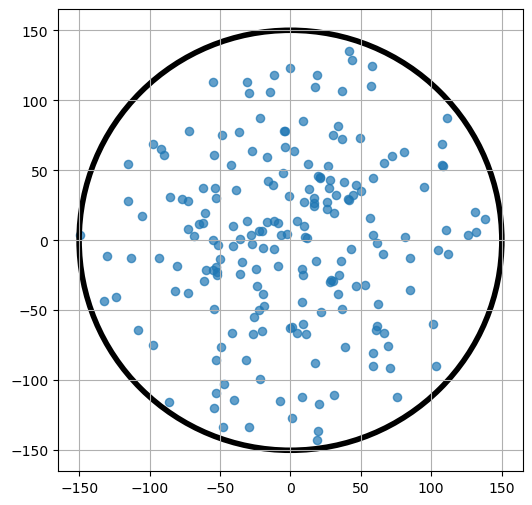

In [29]:
radius = 150.0
n_a = 200
n_d = 3
R = np.sqrt(np.pi*radius**2 / 200)
scaled_radius = radius / R
print(scaled_radius)
print(60. / R)

std_dev = radius / 2.
cov_matrix = (std_dev ** 2) * np.eye(2)

if os.path.isfile("../../configs/acceptor_normal.txt"):
    pass
else:
    file = open("../../configs/acceptor_normal.txt", "x")

acceptor_pos = []

with open("../../configs/acceptor_normal.txt", "w") as f:
    while len(acceptor_pos) < 200:
        X = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_matrix)
        if np.sqrt(X[0]**2 + X[1]**2) <= radius:
            acceptor_pos.append(X)

with open("../../configs/acceptor_normal.txt", "w") as f:
    for _pos in acceptor_pos:
        f.write(f"{_pos[0]}\t{_pos[1]}\n")

acceptors_array = np.array(acceptor_pos)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(acceptors_array[:,0], acceptors_array[:,1], s=35., alpha=.7)
ax.grid(True)
#ax.set_facecolor("lightgrey")    
boundary = patches.Circle((0, 0), radius=radius+0.15, fill=False, edgecolor="k", lw=4)
ax.add_patch(boundary)


NameError: name 'radius' is not defined

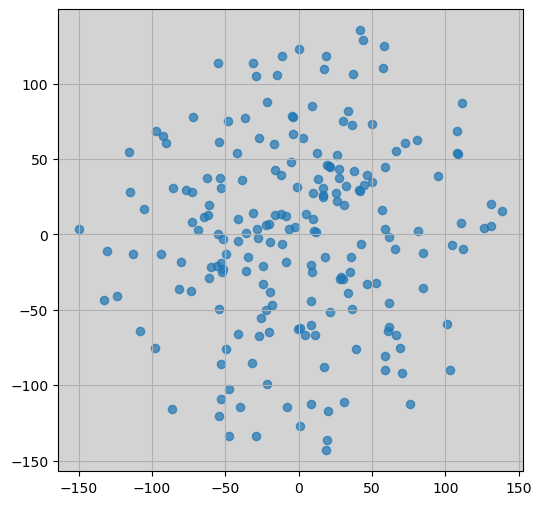

In [2]:
coordinates = []

with open("../../configs/acceptor_normal.txt", "r") as f:
    for _l in f:
        line = _l.strip().split()

        coords = np.array([float(line[0]), float(line[1])])
        coordinates.append(coords)

coordinate_array = np.array(coordinates)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(coordinate_array[:,0], coordinate_array[:,1], s=35., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = patches.Circle((0, 0), radius=radius+0.15, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


['ID', 'inputs', 'outputs']
200


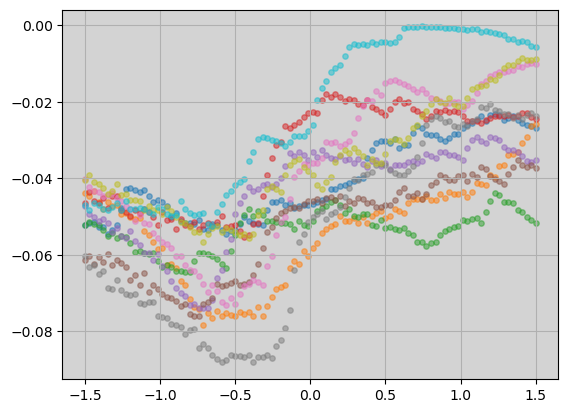

In [4]:
data = np.load("../../data/batch_11000.npz")
inputs = data["inputs"]

print(data.files)
num = len(data["outputs"][0,:])
print(inputs.shape[0])

vs = np.linspace(-1.5, 1.5, num)

plot_kwargs = {
    "s": 15,
    "alpha": .5,
}

fig, ax = plt.subplots()

for i in range(150, 160):
    ax.scatter(vs, data["outputs"][i, :], **plot_kwargs)
ax.grid()
ax.set_facecolor("lightgrey")

In [5]:
if os.path.isfile("../../configs/voltages.txt"):
    pass
else:
    file = open("../../configs/voltages.txt", "x")

min_voltage = -1.5
max_voltage = 1.5

num_of_points = 500

voltages = np.linspace(min_voltage, max_voltage, num_of_points)
#print(voltages)

with open("../../configs/voltages.txt", "w") as f:
    for v in voltages:
        f.write(f"{v}\n")